In [165]:
# All notebooks start with the cell below to initialize database engine

from dotenv import load_dotenv
import os
from sqlalchemy import create_engine, Engine
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

load_dotenv("../.env")

# start psql engine to grab data from database
def get_engine() -> Engine:
    '''
    Depending on .env, it will load localhost or online DB
    priority is online DB
    '''
    DATABASE_URL = os.environ.get("DATABASE_URL")

    if not DATABASE_URL:
        DB_USER = os.environ.get("DB_USER")
        DB_PASSWORD = os.environ.get("DB_PASSWORD")
        DB_HOST = os.environ.get("DB_HOST", "localhost")
        DB_PORT = os.environ.get("DB_PORT", "5432")
        DB_NAME = os.environ.get("DB_NAME")

        if not all([DB_USER, DB_PASSWORD, DB_NAME]):
            raise RuntimeError(
                "Set either DATABASE_URL, or DB_USER/DB_PASSWORD/DB_NAME in .env"
            )

        DATABASE_URL = f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

    else:
        DATABASE_URL = f"postgresql+psycopg2://{DATABASE_URL}"

    return create_engine(DATABASE_URL)

engine = get_engine()

## Of the Asian coffee-producing countries, how much of their own coffee do they actually drink?

Using `coffee_domestic_consumption` (consumption of coffee producing countries' table) against `coffee_production`, for the 10 Asian countries present in the dataset. A value under 100% means the country produces more coffee than it consumes at home; over 100% means local demand outstrips local production, so the country relies on imports to cover the gap even though it's classified as a coffee producer.

In [166]:
# extract coffee_domestic_consumption and coffee_production tables with all columns from proesgres database
domestic = pd.read_sql("SELECT * FROM coffee_domestic_consumption", engine)
production = pd.read_sql("SELECT * FROM coffee_production", engine)

# a list of all coffee producing asian countries
asia_producers = [
    "India", "Indonesia", "Lao People's Democratic Republic", "Nepal",
    "Philippines", "Sri Lanka", "Thailand", "Timor-Leste", "Vietnam", "Yemen",
]

# filter out rows containing asian countries in domestic table and extract them out with only country and total_consumption column
asia_domestic = domestic[domestic["country"].isin(asia_producers)][["country", "total_domestic_consumption"]]
asia_domestic

,country,total_domestic_consumption
5,Indonesia,4920480000
12,Timor-Leste,294000
18,Philippines,2807280000
36,India,2093460000
39,Lao People's Democratic Republic,157980000
42,Nepal,0
47,Sri Lanka,58300020
48,Thailand,1248600000
53,Vietnam,1920928320
54,Yemen,121620000


In [167]:
# filter out rows containing asian countries in production table and extract them out with only country and total_production column
asia_production = production[production["country"].isin(asia_producers)][["country", "total_production"]]
asia_production

,country,total_production
5,Indonesia,1.540488e+10
12,Timor-Leste,6.864000e+07
18,Philippines,8.907000e+08
36,India,8.222220e+09
39,Lao People's Democratic Republic,5.680800e+08
42,Nepal,1.440000e+06
47,Sri Lanka,7.386000e+07
48,Thailand,1.674000e+09
53,Vietnam,2.880318e+10
54,Yemen,1.909200e+08


In [168]:
# merge domestic consumption df with production df
asia = asia_domestic.merge(asia_production, on="country")
asia

,country,total_domestic_consumption,total_production
0,Indonesia,4920480000,1.540488e+10
1,Timor-Leste,294000,6.864000e+07
2,Philippines,2807280000,8.907000e+08
3,India,2093460000,8.222220e+09
4,Lao People's Democratic Republic,157980000,5.680800e+08
5,Nepal,0,1.440000e+06
6,Sri Lanka,58300020,7.386000e+07
7,Thailand,1248600000,1.674000e+09
8,Vietnam,1920928320,2.880318e+10
9,Yemen,121620000,1.909200e+08


In [169]:
# create new percentage column calculating how much of coffee is consumed domestically out of the coffee produced
asia["pct_domestic"] = asia["total_domestic_consumption"] / asia["total_production"] * 100

# round the % to whole number
asia["pct_domestic"] = asia["pct_domestic"].round(0).astype(int)
asia

,country,total_domestic_consumption,total_production,pct_domestic
0,Indonesia,4920480000,1.540488e+10,32
1,Timor-Leste,294000,6.864000e+07,0
2,Philippines,2807280000,8.907000e+08,315
3,India,2093460000,8.222220e+09,25
4,Lao People's Democratic Republic,157980000,5.680800e+08,28
5,Nepal,0,1.440000e+06,0
6,Sri Lanka,58300020,7.386000e+07,79
7,Thailand,1248600000,1.674000e+09,75
8,Vietnam,1920928320,2.880318e+10,7
9,Yemen,121620000,1.909200e+08,64


In [170]:
# replace Laos name as it is too long
laos_name = {"Lao People's Democratic Republic": "Laos"}
asia["country"] = asia["country"].replace(laos_name)

#sort % by descending
asia = asia.sort_values("pct_domestic", ascending=False)
asia

,country,total_domestic_consumption,total_production,pct_domestic
2,Philippines,2807280000,8.907000e+08,315
6,Sri Lanka,58300020,7.386000e+07,79
7,Thailand,1248600000,1.674000e+09,75
9,Yemen,121620000,1.909200e+08,64
0,Indonesia,4920480000,1.540488e+10,32
4,Laos,157980000,5.680800e+08,28
3,India,2093460000,8.222220e+09,25
8,Vietnam,1920928320,2.880318e+10,7
1,Timor-Leste,294000,6.864000e+07,0
5,Nepal,0,1.440000e+06,0


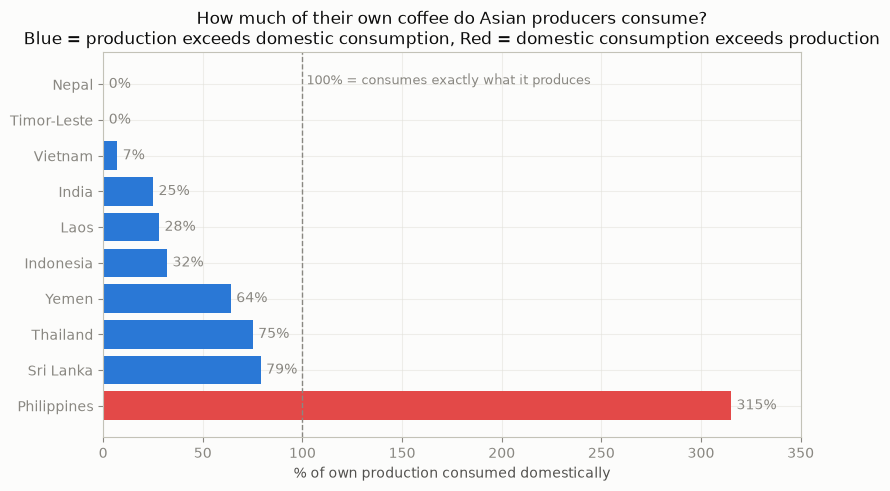

In [171]:
#colour codes
blue, red = "#2a78d6", "#e34948"
muted = "#898781"

# red colour if % is more than 100 or blue if less than 100
colors = [red if value > 100 else blue for value in asia["pct_domestic"]]

# plot a horizontal bar chart with countries as y-axis and % as x-axis with bar colour following colors list above and data labels
plt.figure(figsize=[9, 5])
bars = plt.barh(asia["country"], asia["pct_domestic"], color=colors, height=0.8)
plt.bar_label(bars, fmt='%g%%', padding=4, color = muted)

# draw a vertical dashed line at x=100% and display a text for the line
plt.axvline(100, color=muted, linewidth=1, linestyle="--")
plt.text(100, 9, " 100% = consumes exactly what it produces",
        color=muted, fontsize=9)

# set label and length of x-axis as well title of chart
plt.xlabel("% of own production consumed domestically")
plt.xlim(0, 350)
plt.title(
    "How much of their own coffee do Asian producers consume?\n"
    "Blue = production exceeds domestic consumption, Red = domestic consumption exceeds production"
)

plt.show()